In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

from llr_study.utils import *

In [ ]:
%config InlineBackend.figure_format = 'retina'

In [3]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = [
    'LLR_crtd_odd',
    # 'LLR_odd_combos2to5',
    # 'LLR_odd_combos6',
    # 'LLR_odd_combos7to12',
]
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = parse_UL_results_files(file_paths)

# Save to CSV for further analysis
# output_file = "combined_llr_results.csv"
# df.to_csv(output_file, index=False)
# print(f"\nResults saved to {output_file}")


Total observables parsed: 729
llr_from_3D    543
llr_from_2D    120
llr_from_1D     66
Name: obs_type, dtype: int64


In [11]:
df

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,bjets_mbb_vs_bjets_dR_llr,322.2,231.2,449.4,173.7,604.8,llr_from_2D,2
1,bjets_mean_pt_vs_bjets_dR_llr,337.9,242.8,471.2,182.8,634.2,llr_from_2D,2
2,bjets_mean_pt_vs_bjets_mbb_llr,344.9,247.8,481.1,186.6,647.4,llr_from_2D,2
3,bjets_dR_vs_bjets_pt_bb_llr,353.0,253.6,492.3,191.0,658.0,llr_from_2D,2
4,bjets_mbb_vs_bjets_pt_bb_llr,358.8,257.8,500.4,194.1,671.2,llr_from_2D,2
...,...,...,...,...,...,...,...,...
724,all_pt_llr,4000.0,3453.0,6902.0,2570.0,9409.0,llr_from_1D,1
725,all_sT_vs_bjet_bijet_dR_vs_bb_lnu_dPhi_llr,4000.0,2743.0,7157.0,1977.0,12120.0,llr_from_3D,3
726,all_sT_vs_bjet_bijet_dR_vs_bjets_dPhi_llr,4000.0,3425.0,8050.0,2289.0,12130.0,llr_from_3D,3
727,nAK4_llr,4000.0,3982.0,8050.0,3719.0,12130.0,llr_from_1D,1


Scatter plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_scatterplot_by_type.pdf


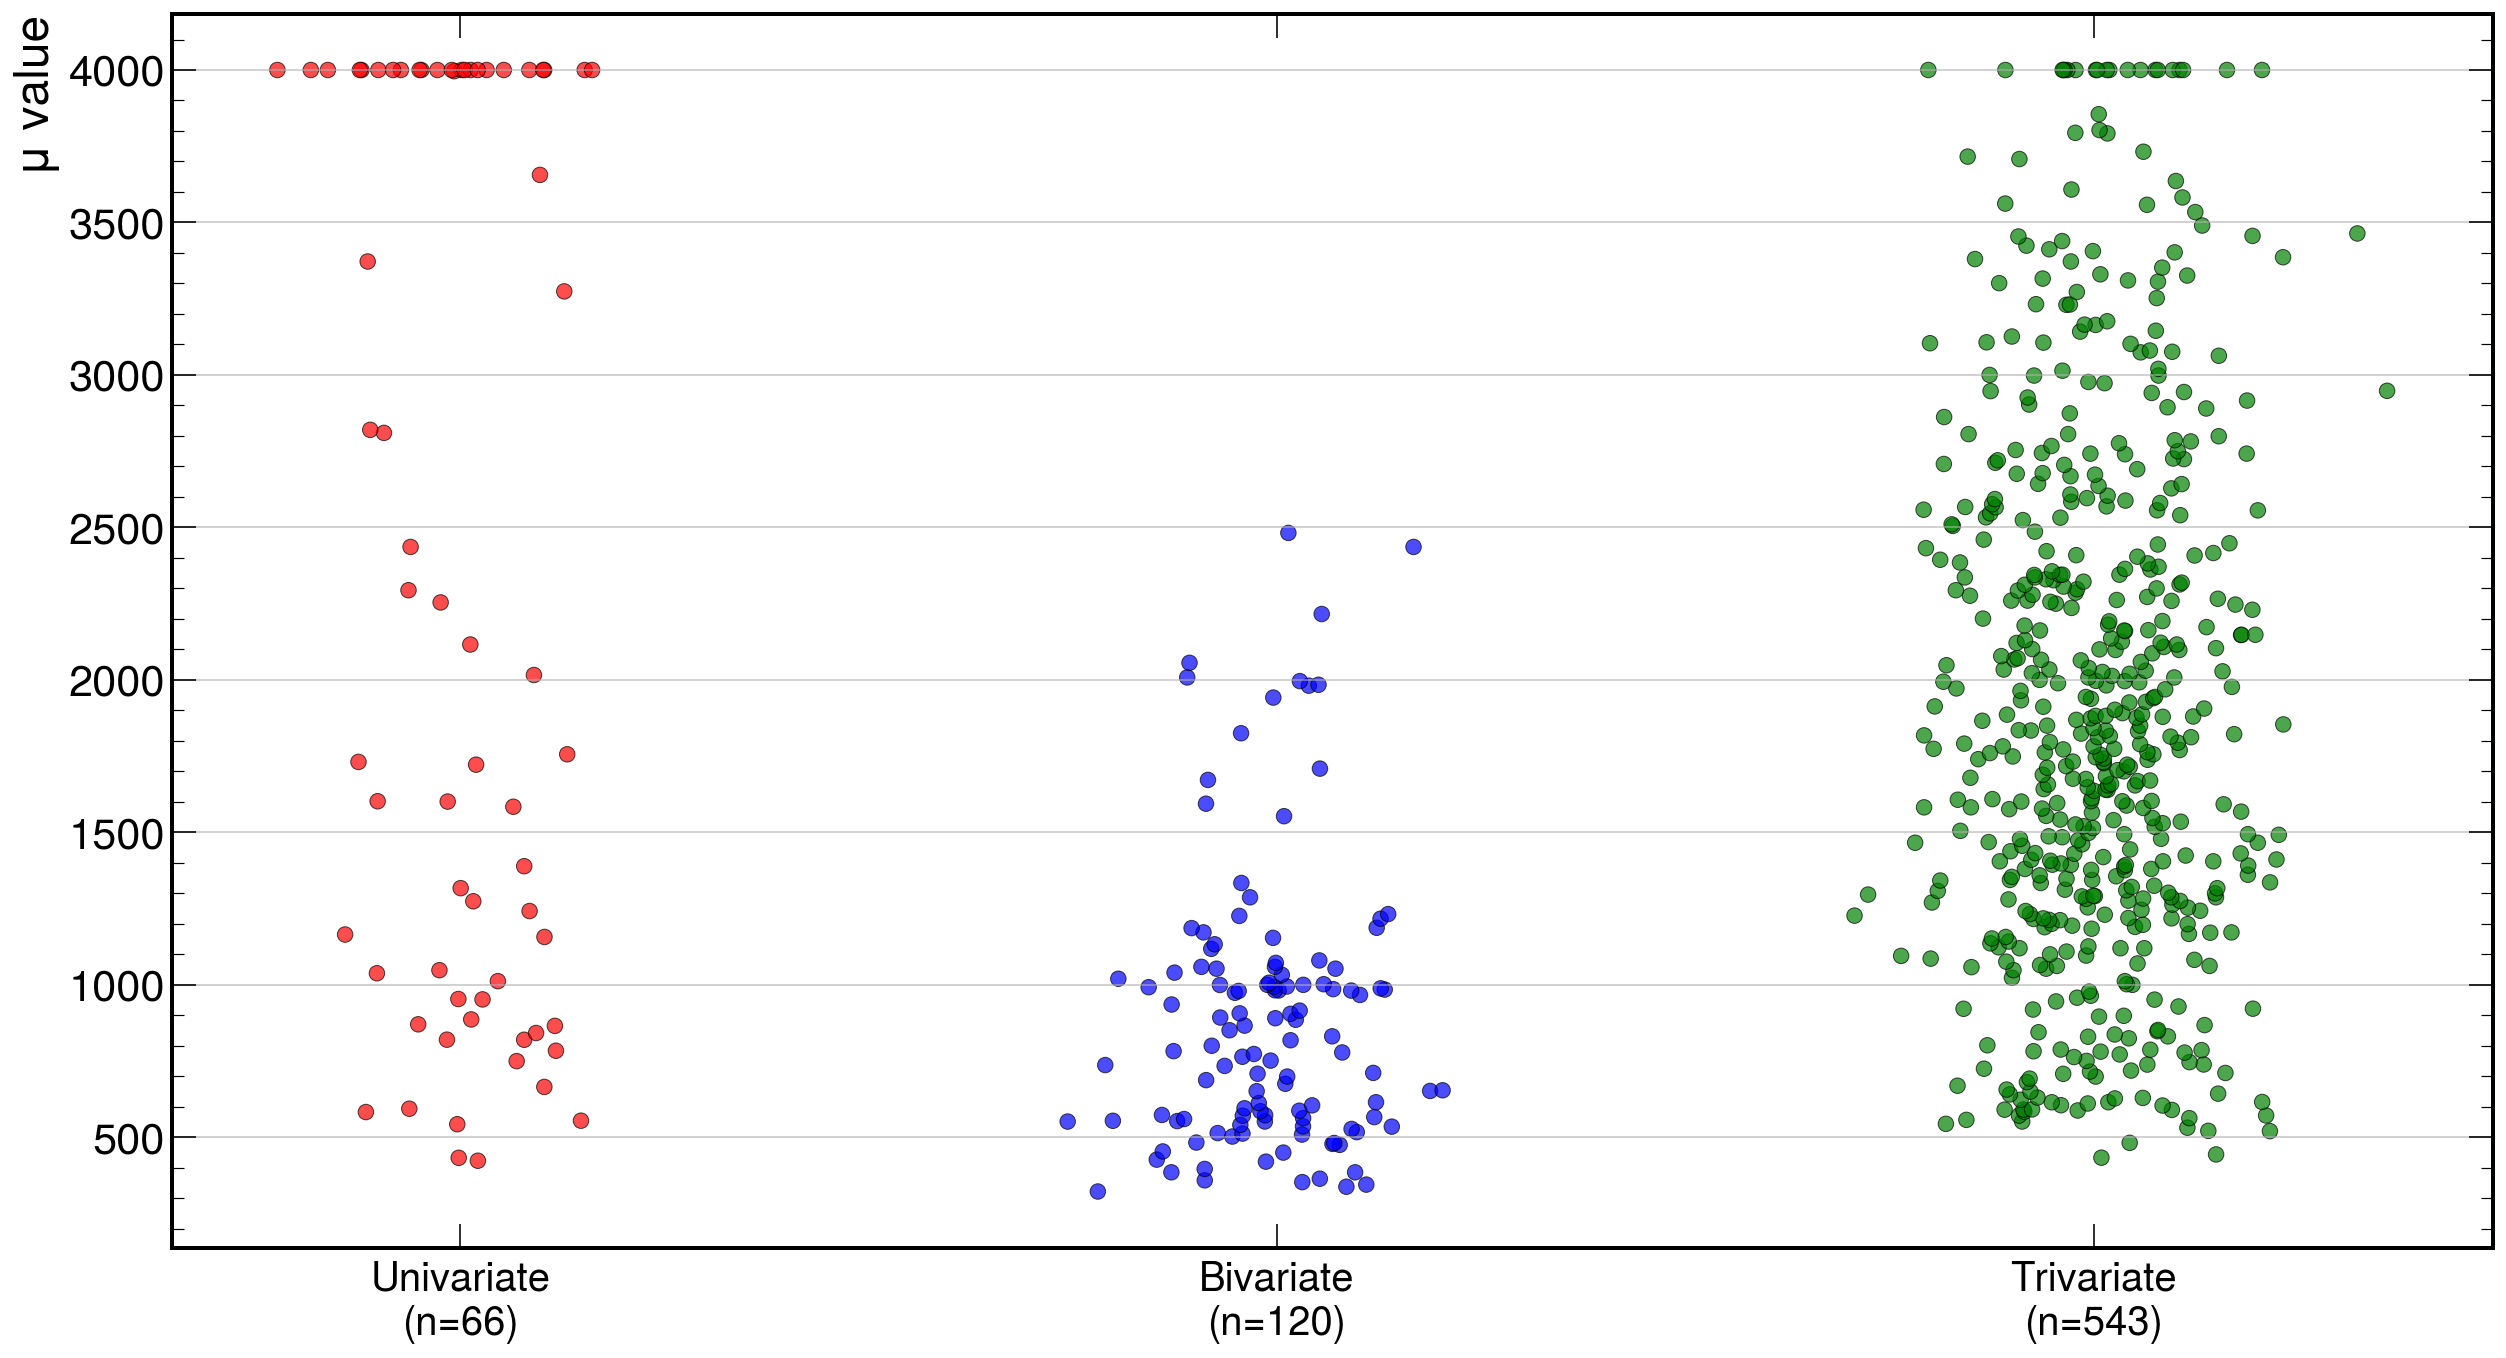

In [7]:
create_UL_scatter_plot_by_type(df, projectdir)

Descriptive box plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_boxplot_by_type.pdf


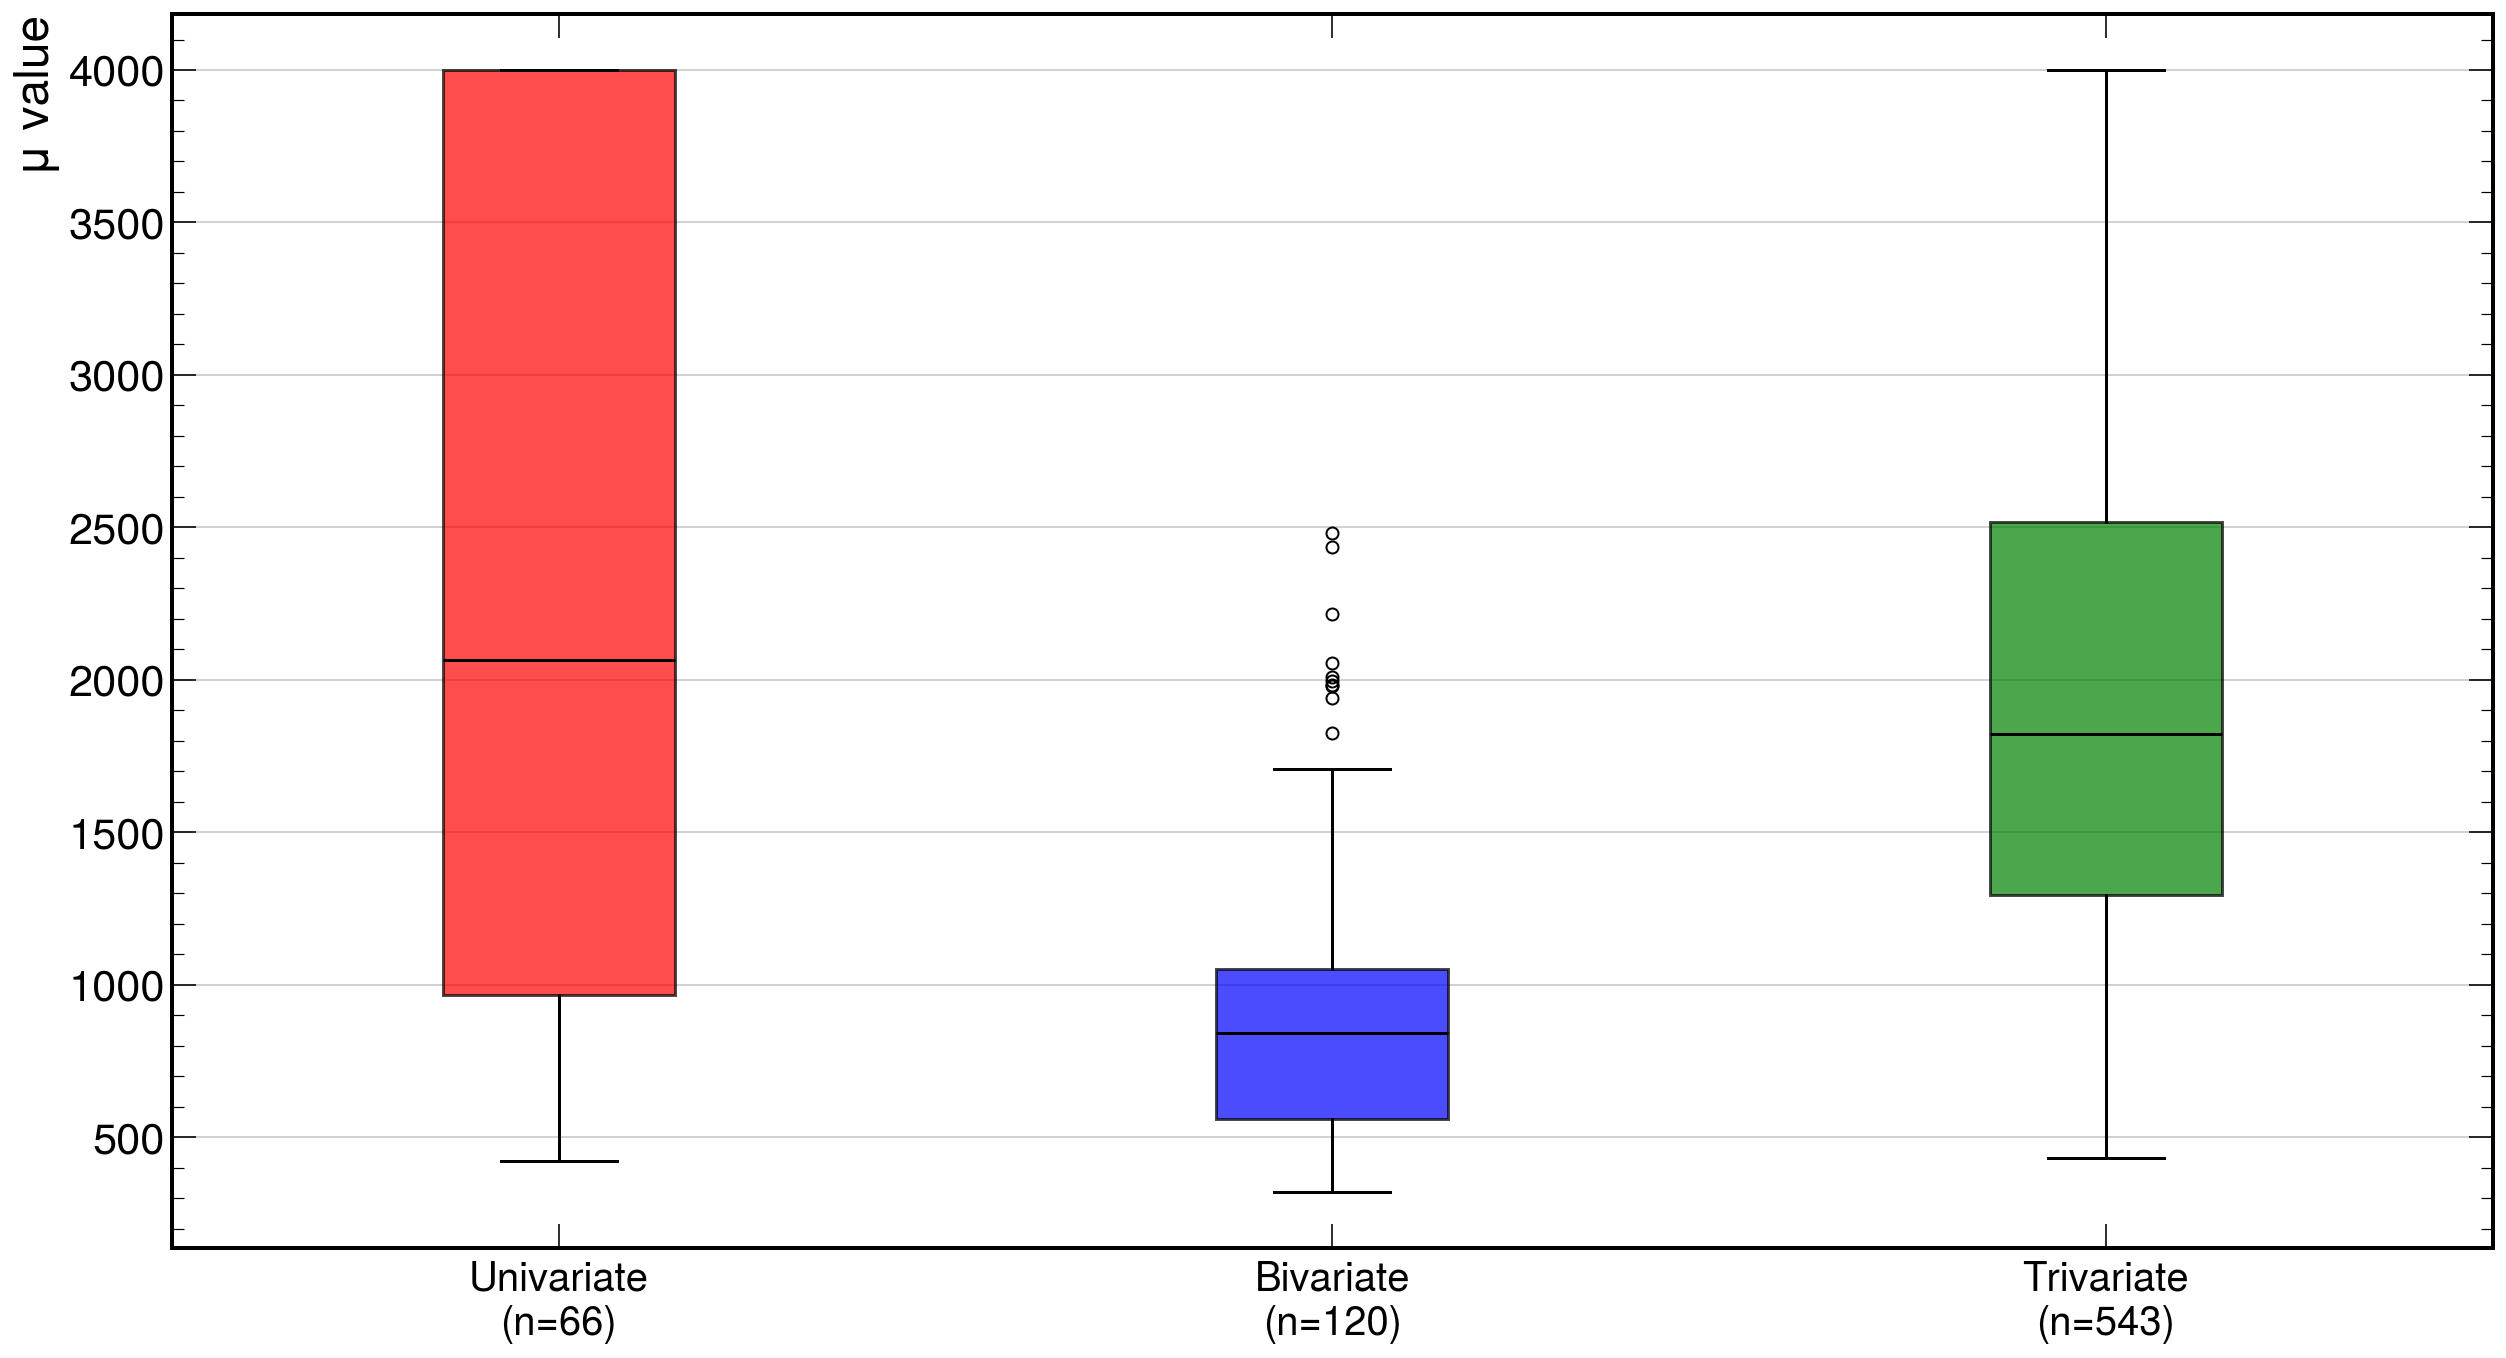

In [8]:
create_UL_box_plot_by_type(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_multivar_trend.pdf


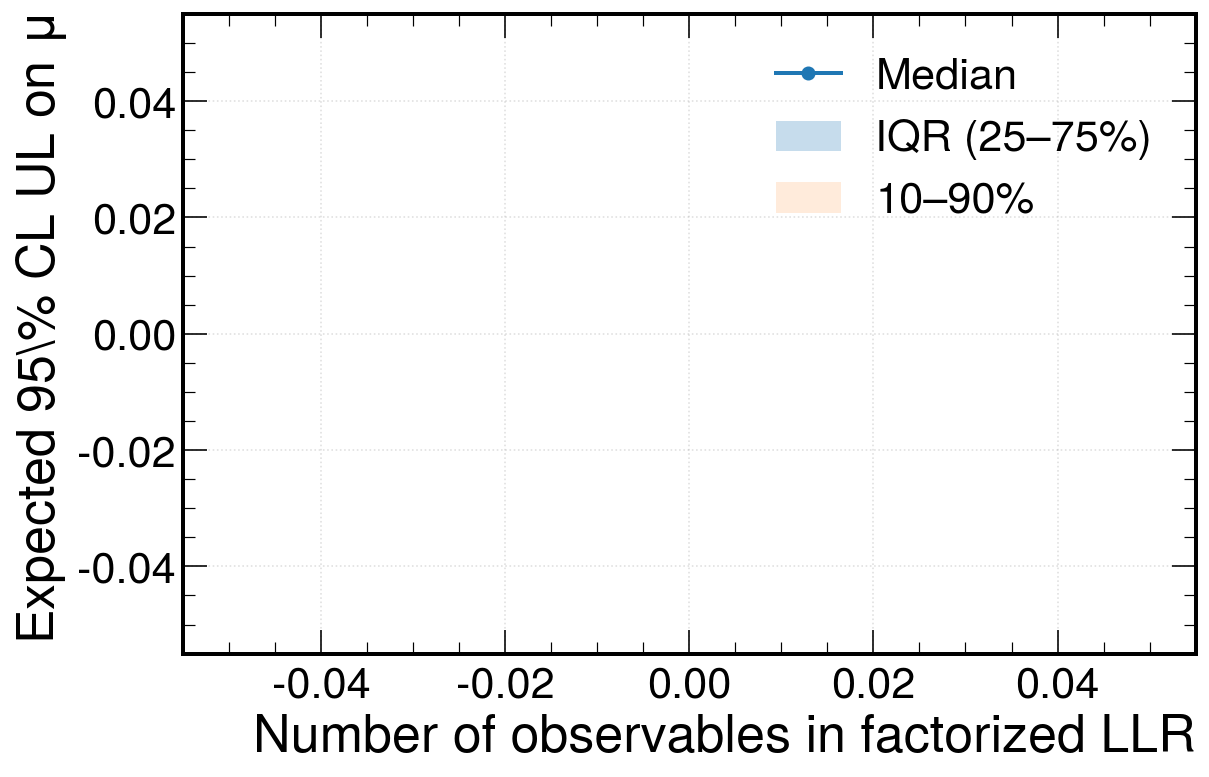

In [9]:
plot_multivar_trend(df, projectdir)

Hierarchical 1D plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/hierarchical_1D_llrs.pdf


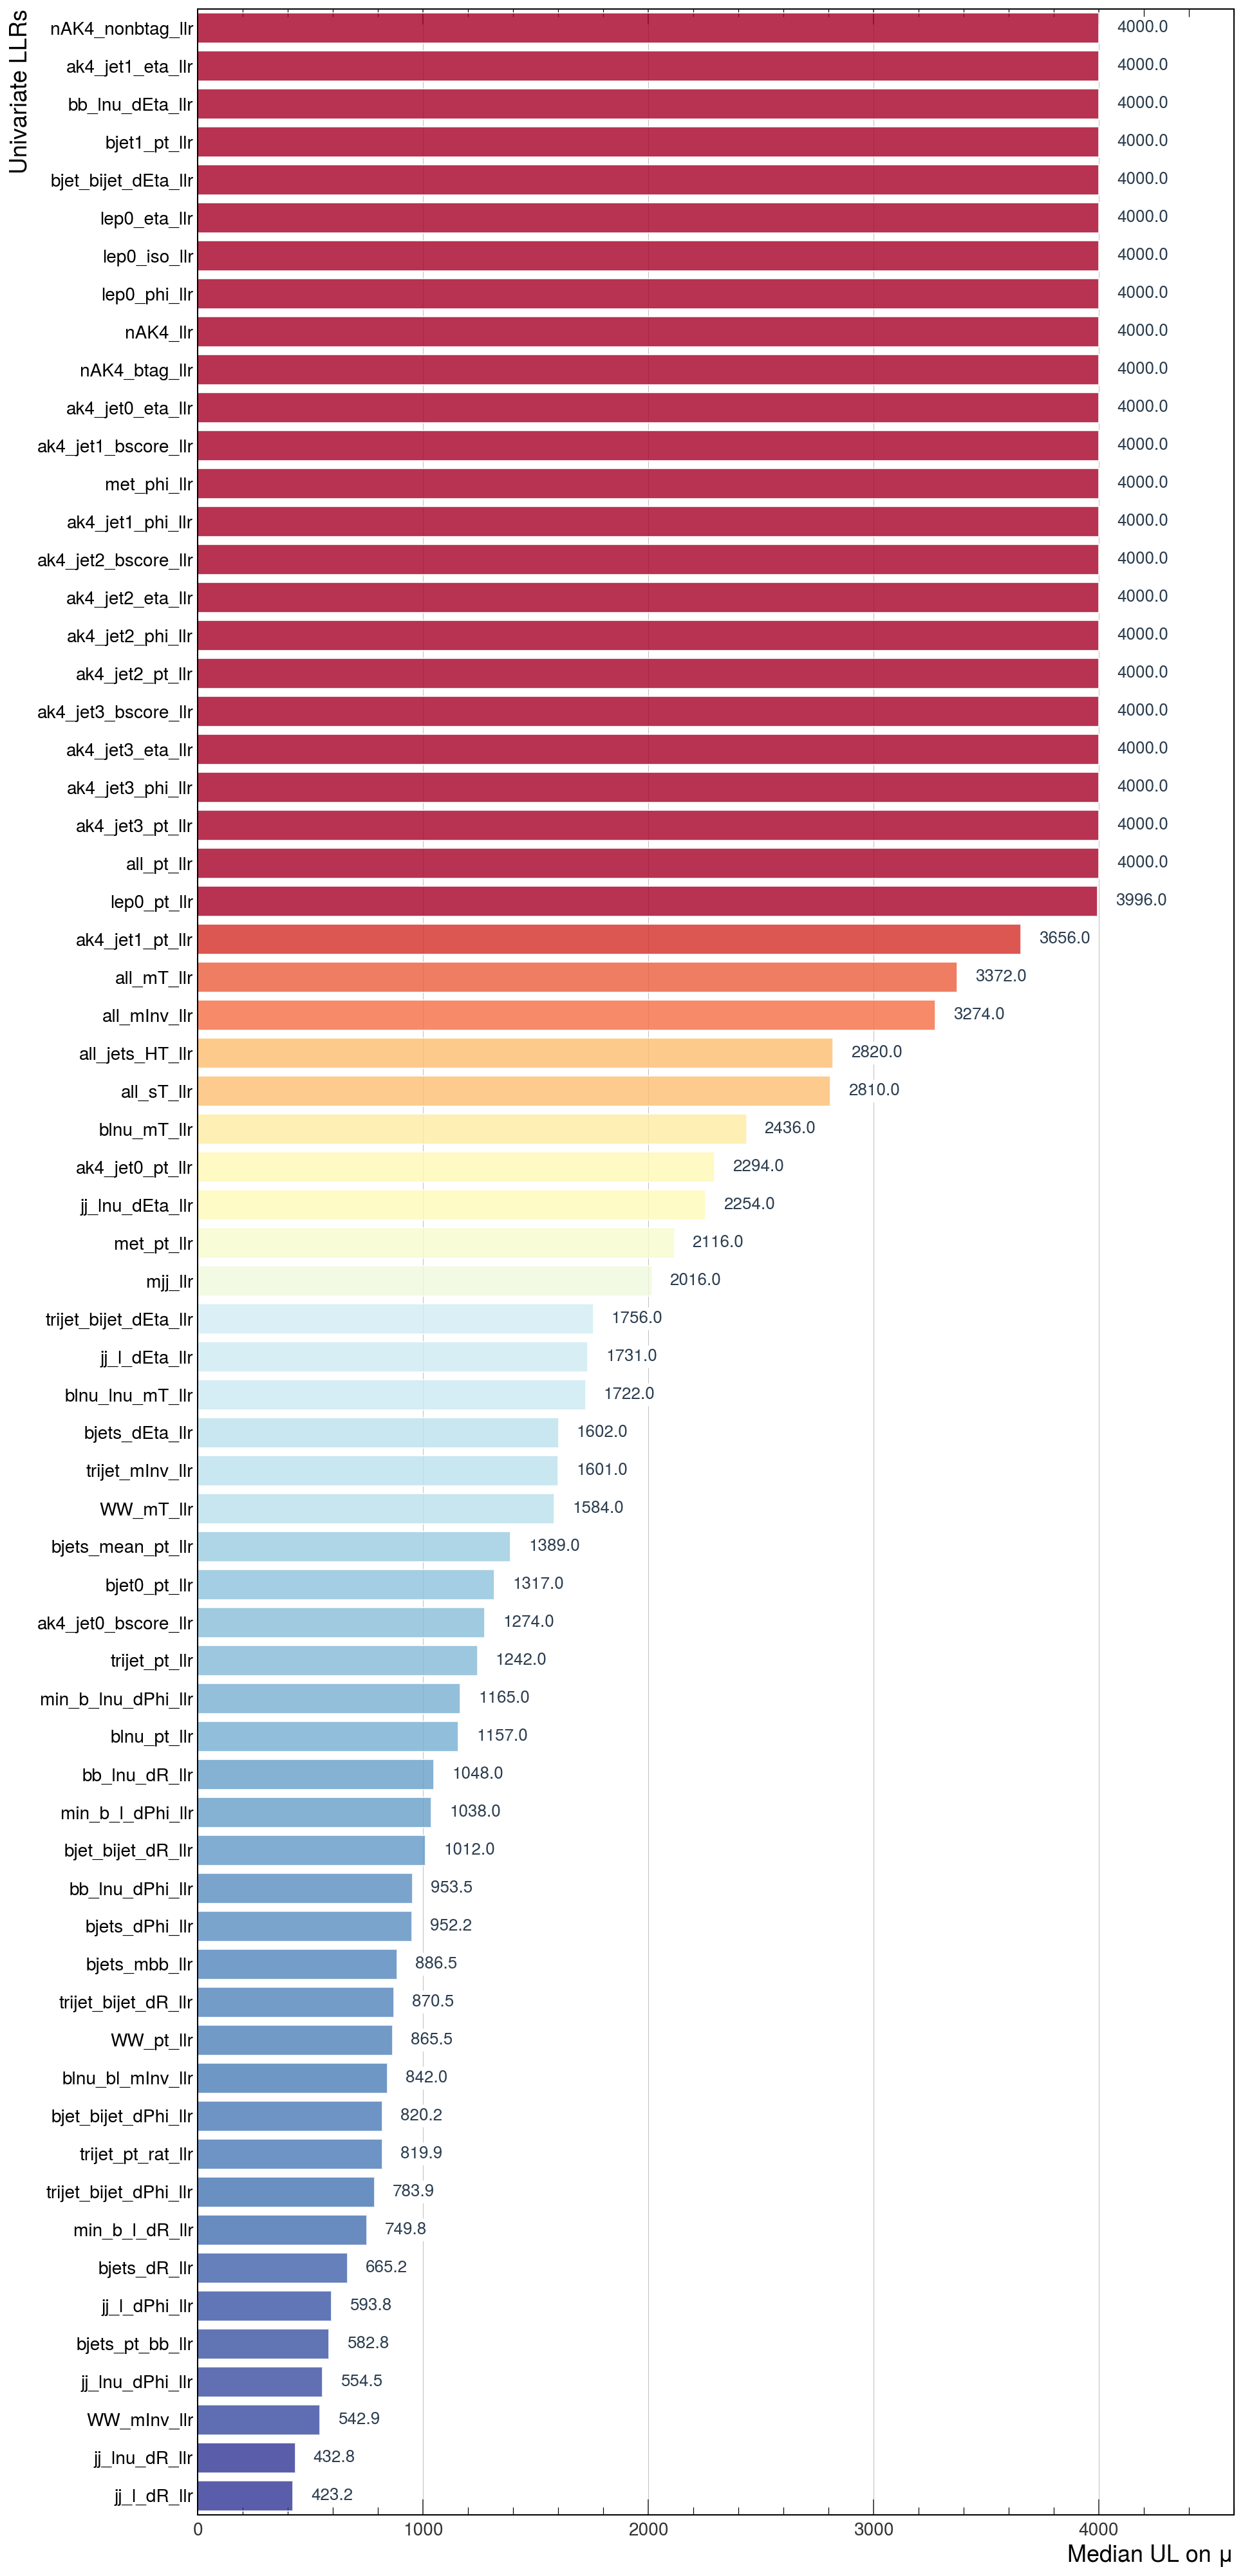

In [19]:
def this_create_hierarchical_1D_plot(df: pd.DataFrame, output_dir):
    """Create hierarchical plot showing individual 1D LLRs with names."""
    
    label_fontsize = 18
    tick_fontsize = 14
    
    # Filter for only 1D LLRs
    subset_1d = df[df['obs_type'] == 'llr_from_1D'].copy()
    
    if subset_1d.empty:
        print("No 1D LLRs found in dataset")
        return
    
    # Sort by mu (best to worst)
    subset_1d = subset_1d.sort_values('mu')
    
    fig, ax = plt.subplots(figsize=(14, len(subset_1d) * 0.4 + 2))
    
    # Create a gradient color scheme based on performance
    # Better performers (lower mu) get cooler colors, worse performers get warmer colors
    import matplotlib.cm as cm
    
    # Normalize values for color mapping
    norm = plt.Normalize(vmin=subset_1d['mu'].min(), vmax=subset_1d['mu'].max())
    colors = cm.RdYlBu_r(norm(subset_1d['mu']))  # Reverse so red=bad, blue=good
    
    # Alternative single nice colors (uncomment one):
    # colors = '#4472C4'  # Professional blue
    # colors = '#70AD47'  # Professional green  
    # colors = '#E15759'  # Professional coral
    # colors = '#F79646'  # Professional orange
    # colors = '#9F81C4'  # Professional purple
    # colors = '#5B9BD5'  # Light professional blue
    
    # Create horizontal bar plot
    y_positions = range(len(subset_1d))
    bars = ax.barh(y_positions, subset_1d['mu'], 
                   color=colors, alpha=0.8, edgecolor='white', linewidth=1.0)
    
    names = [name for name in subset_1d['obs_name']]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(names, fontsize=tick_fontsize)
    
    # Remove y-axis tick marks but keep all spines for a complete frame
    ax.tick_params(axis='y', which='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        # spine.set_color('#CCCCCC')  # Light gray frame
    # Set limits
    ax.set_ylim(-0.5, len(subset_1d) - 0.5)
    max_value = max(subset_1d['mu'])
    ax.set_xlim(0, max_value * 1.15)
    
    # Enhanced styling
    ax.set_xlabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_ylabel('Univariate LLRs', fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize, colors='#333333')
    
    # Subtle grid
    ax.grid(True, alpha=0.5, axis='x', linestyle='-', linewidth=0.5, color='gray')
    ax.set_axisbelow(True)  # Put grid behind bars
    
    # Enhanced title
    # ax.set_title(f'Univariate LLR Performance (n={len(subset_1d)})', fontsize=label_fontsize+2, fontweight='bold', pad=25, color='#2C3E50')
    
    # Better positioned value labels with background for readability
    for i, (bar, value) in enumerate(zip(bars, subset_1d['mu'])):
        # Add subtle background box for text
        text = ax.text(value + max_value * 0.02, i, f'{value:.1f}', 
                      va='center', ha='left', fontsize=tick_fontsize-1, 
                    #   fontweight='bold', 
                      color='#2C3E50',
                      bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))
    
    # Set figure background
    # fig.patch.set_facecolor('white')
    # ax.set_facecolor('#FAFAFA')  # Very light gray background
    
    plt.tight_layout()
    
    save_path = output_dir / "hierarchical_1D_llrs.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Hierarchical 1D plot saved to {save_path}")
    
    plt.show()

this_create_hierarchical_1D_plot(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_global_scatter.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_variable_usage_top10.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_greedy_chain.pdf


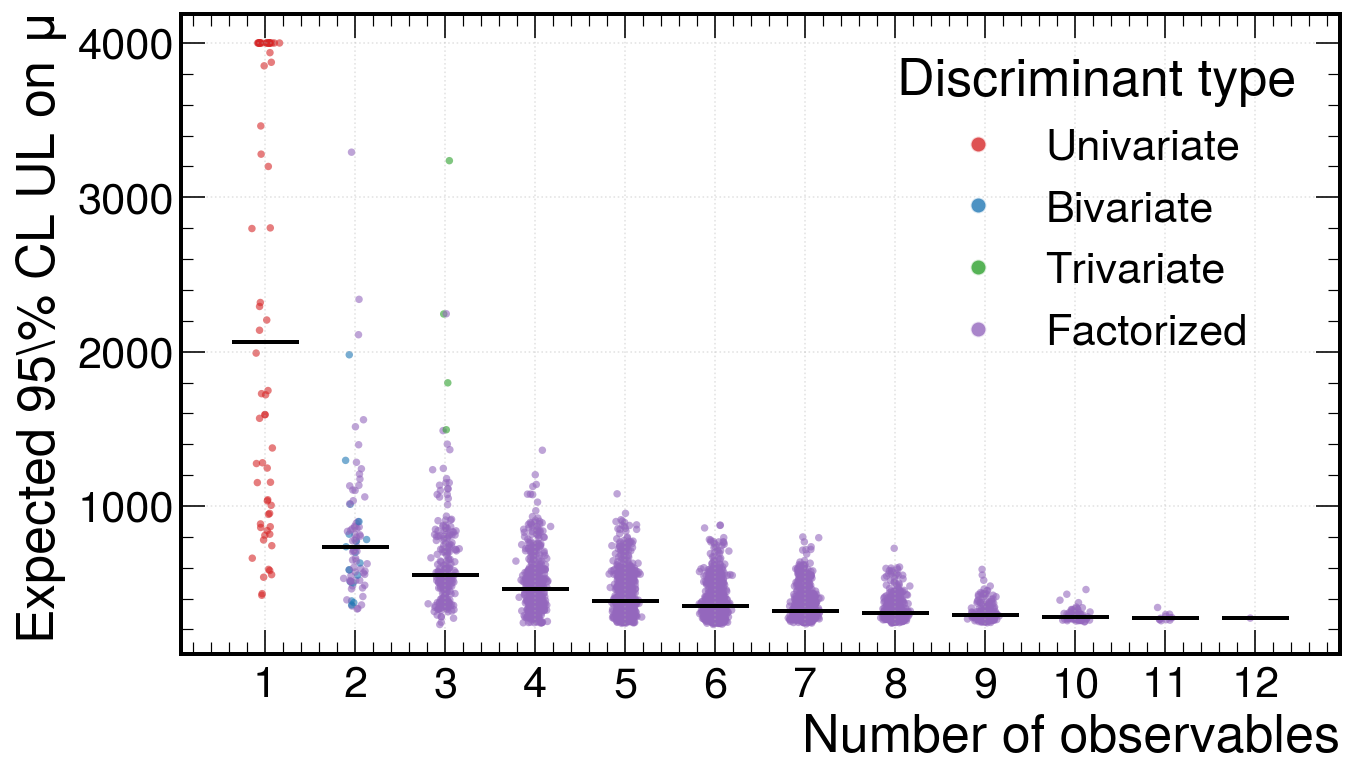

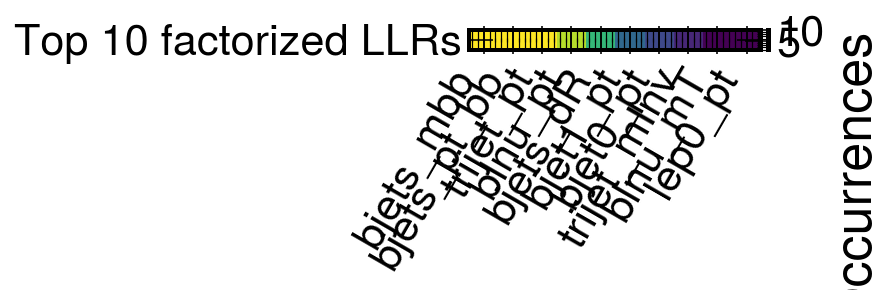

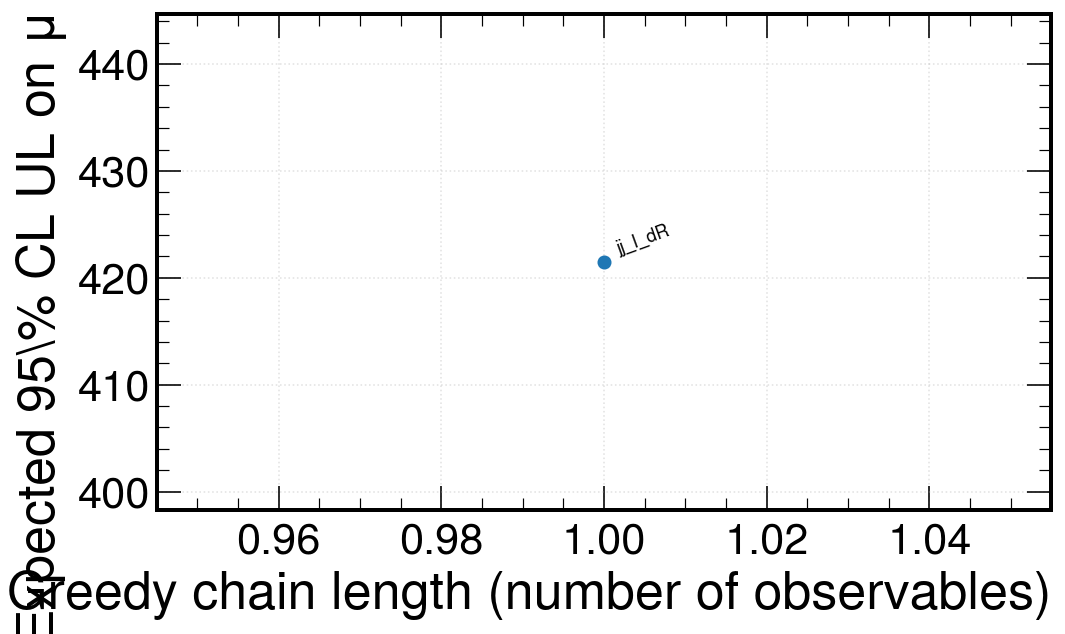

In [11]:
plot_global_scatter(df, projectdir)
plot_variable_usage_heatmap(df, projectdir, 10)
plot_greedy_chain(df, projectdir, max_k=10)

In [19]:
# Create a clean ranking DataFrame
from_1d_ranking = df[df['llr_type'] == 'from_1D'][['llr_name', 'mu_value']].copy()
from_1d_ranking = from_1d_ranking.sort_values('mu_value').reset_index(drop=True)
from_1d_ranking['rank'] = range(1, len(from_1d_ranking) + 1)
from_1d_ranking = from_1d_ranking[['rank', 'llr_name', 'mu_value']]

# Display
print(from_1d_ranking.to_string(index=False))

 rank              llr_name  mu_value
    1           jj_l_dR_llr  421.5000
    2         jj_lnu_dR_llr  432.0000
    3           WW_mInv_llr  538.2500
    4       jj_lnu_dPhi_llr  554.9375
    5       bjets_pt_bb_llr  581.7500
    6         jj_l_dPhi_llr  589.2500
    7          bjets_dR_llr  661.7500
    8        min_b_l_dR_llr  742.7500
    9 trijet_bijet_dPhi_llr  779.7500
   10     trijet_pt_rat_llr  809.7500
   11   bjet_bijet_dPhi_llr  817.2500
   12      blnu_bl_mInv_llr  840.2500
   13             WW_pt_llr  860.7500
   14   trijet_bijet_dR_llr  865.7500
   15         bjets_mbb_llr  883.7500
   16        bjets_dPhi_llr  945.7500
   17       bb_lnu_dPhi_llr  951.8750
   18     bjet_bijet_dR_llr 1004.5000
   19      min_b_l_dPhi_llr 1033.0000
   20         bb_lnu_dR_llr 1040.2500
   21           blnu_pt_llr 1151.5000
   22    min_b_lnu_dPhi_llr 1153.7500
   23         trijet_pt_llr 1245.7500
   24   ak4_jet0_bscore_llr 1275.0000
   25          bjet0_pt_llr 1280.0000
   26     bj

In [26]:
top_10_1d_llrs = from_1d_ranking['llr_name'][:10].to_list()
top_10_1d_llrs


['jj_l_dR_llr',
 'jj_lnu_dR_llr',
 'WW_mInv_llr',
 'jj_lnu_dPhi_llr',
 'bjets_pt_bb_llr',
 'jj_l_dPhi_llr',
 'bjets_dR_llr',
 'min_b_l_dR_llr',
 'trijet_bijet_dPhi_llr',
 'trijet_pt_rat_llr']

In [22]:
reserved = [
    'lep0_pt',                                      
    'bjets_mbb', 'bjets_dR', 'bjets_pt_bb', 'bjet0_pt', 'bjet1_pt',         # bjet-vars
    'blnu_mT', 'blnu_pt',                                                   # leptonic-top 
    'trijet_mInv', 'trijet_pt', 'trijet_pt_rat', 'trijet_bijet_dR'          # hadronic-top 
]
# Create the full LLR names by adding '_llr' suffix
reserved_llr_names = [var + '_llr' for var in reserved]

# Filter the ranking for only the reserved LLRs
reserved_ranking = from_1d_ranking[from_1d_ranking['llr_name'].isin(reserved_llr_names)].copy()

# Display the results
print(f"Ranking of Reserved LLRs ({len(reserved_ranking)} out of {len(reserved)} found):")
print("-" * 60)
for _, row in reserved_ranking.iterrows():
    print(f"{row['rank']:2d}. {row['llr_name']:<25} μ = {row['mu_value']:8.3f}")

# Check if any reserved LLRs are missing
missing_llrs = set(reserved_llr_names) - set(reserved_ranking['llr_name'])
if missing_llrs:
    print(f"\nMissing from 1D rankings: {missing_llrs}")

Ranking of Reserved LLRs (12 out of 12 found):
------------------------------------------------------------
 5. bjets_pt_bb_llr           μ =  581.750
 7. bjets_dR_llr              μ =  661.750
10. trijet_pt_rat_llr         μ =  809.750
14. trijet_bijet_dR_llr       μ =  865.750
15. bjets_mbb_llr             μ =  883.750
21. blnu_pt_llr               μ = 1151.500
23. trijet_pt_llr             μ = 1245.750
25. bjet0_pt_llr              μ = 1280.000
28. trijet_mInv_llr           μ = 1591.500
37. blnu_mT_llr               μ = 2318.500
44. lep0_pt_llr               μ = 3875.000
52. bjet1_pt_llr              μ = 4000.000
